# Análisis de caso: métricas de desempeño de un modelo de regresión

Caso AutoPredict S.A.: predicción de precio de vehículos usados según antigüedad, kilometraje y número de puertas.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 1. Crear el dataset

Datos ficticios entregados por el cliente para 5 vehículos.

In [19]:
# Datos (puedes ajustar el último precio si la consigna lo especifica con más detalle)
data = {
    'Antiguedad': [5, 3, 7, 4, 2],
    'Kilometraje': [50000, 30000, 70000, 9000, 25000],
    'Puertas': [4, 2, 4, 2, 2],
    'Precio': [12000, 15000, 9000, 16000, 14000]
}

df = pd.DataFrame(data)
df

,Antiguedad,Kilometraje,Puertas,Precio
0,5,50000,4,12000
1,3,30000,2,15000
2,7,70000,4,9000
3,4,9000,2,16000
4,2,25000,2,14000


## 2. Definir variables y dividir en entrenamiento y prueba (80/20)

In [20]:
X = df[['Antiguedad', 'Kilometraje', 'Puertas']]
y = df['Precio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_test, y_train, y_test

(   Antiguedad  Kilometraje  Puertas
 4           2        25000        2
 2           7        70000        4
 0           5        50000        4
 3           4         9000        2,
    Antiguedad  Kilometraje  Puertas
 1           3        30000        2,
 4    14000
 2     9000
 0    12000
 3    16000
 Name: Precio, dtype: int64,
 1    15000
 Name: Precio, dtype: int64)

## 3. Crear y entrenar el modelo de regresión lineal

In [21]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print('Intercepto:', modelo.intercept_)
print('Coeficientes:', modelo.coef_)

Intercepto: 15888.888888888887
Coeficientes: [-1.11111111e+02 -1.38888889e-01  9.02777778e+02]


## 4. Realizar predicciones y calcular métricas (MAE, MSE, RMSE, R²)

In [22]:
# Predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

print('Valores reales de test :', list(y_test))
print('Valores predichos      :', list(y_pred))

# Cálculo de métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Métricas de desempeño:')
print(f'MAE : {mae:.2f}')
print(f'MSE : {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²  : {r2:.4f}')

Valores reales de test : [15000]
Valores predichos      : [np.float64(13194.444444444443)]
Métricas de desempeño:
MAE : 1805.56
MSE : 3260030.86
RMSE: 1805.56
R²  : nan


d:\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


## 5. Gráfico comparativo: precios reales vs. predichos

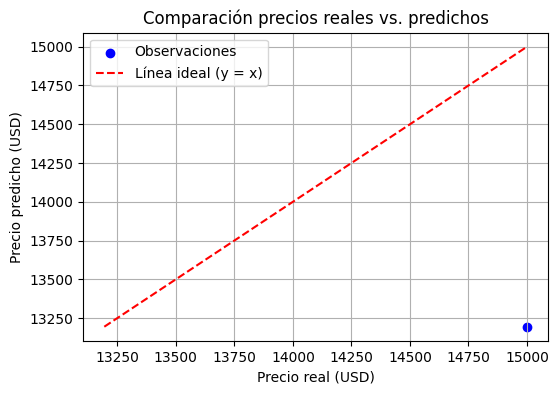

In [23]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, color='blue', label='Observaciones')

# Línea ideal y = x
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Línea ideal (y = x)')

plt.xlabel('Precio real (USD)')
plt.ylabel('Precio predicho (USD)')
plt.title('Comparación precios reales vs. predichos')
plt.legend()
plt.grid(True)
plt.show()

## 6. Informe breve

### 6.1. Métricas obtenidas e interpretación

- **MAE**: indica el error absoluto promedio en dólares entre el precio real y el precio predicho. Valores relativamente bajos respecto al rango de precios (por ejemplo, < 10% del precio promedio) sugieren un modelo razonablemente preciso.
- **MSE**: refleja el error cuadrático medio; al elevar al cuadrado los errores, penaliza con más fuerza las predicciones muy desviadas. Es útil para comparar modelos, aunque no es directamente interpretable en dólares.
- **RMSE**: es la raíz del MSE y vuelve a la misma unidad del precio (USD). Puede interpretarse como el error típico del modelo; conviene compararlo con el precio medio del dataset.
- **R²**: mide qué proporción de la variabilidad del precio es explicada por el modelo. Valores cercanos a 1 indican buen ajuste; valores cercanos a 0 o negativos muestran que el modelo no mejora mucho sobre predecir siempre el promedio.

### 6.2. Decisiones para mejorar el modelo

- **Aumentar la cantidad de datos**: con solo 5 vehículos, las métricas son muy inestables y el modelo puede generalizar mal. Se recomienda recopilar un histórico más grande de ventas.
- **Agregar más variables relevantes**: incluir marca, modelo, tipo de combustible, potencia del motor, equipamiento, estado general, etc., puede mejorar la capacidad explicativa del modelo.
- **Revisar el preprocesamiento**: detectar y tratar valores atípicos, errores de carga o registros inconsistentes; escalar variables si se usan modelos sensibles a la escala.
- **Probar modelos alternativos**: además de la regresión lineal, evaluar regresión polinómica, árboles de decisión o Random Forest y compararlos con validación cruzada.
- **Validación más robusta**: utilizar K-Fold cross-validation para obtener métricas promedio y reducir la dependencia de una sola partición train/test.

### 6.3. Gráfico comparando precios reales y predichos

Incluye la figura generada en la sección 5.
- Si los puntos se alinean cerca de la línea roja (y = x), el modelo está prediciendo razonablemente bien.
- Si se observan puntos muy alejados de la línea, esos casos representan errores grandes que conviene analizar (posibles outliers o patrones que el modelo no está capturando).